In [3]:
def solve_kepler(M, e, tol=1e-10, max_iter=100):
    """
    Solve Kepler's equation E - e sin E = M for eccentric anomaly E using Newton-Raphson.
    M, e can be numpy arrays or floats.
    """
    M = np.array(M)
    E = M.copy()  # Initial guess E ~ M
    
    for _ in range(max_iter):
        f = E - e * np.sin(E) - M
        f_prime = 1 - e * np.cos(E)
        delta = -f / f_prime
        E += delta
        if np.all(np.abs(delta) < tol):
            break
    return E


Running MCMC...


100%|███████████████████████████████████| 50000/50000 [00:23<00:00, 2092.86it/s]


MCMC complete.


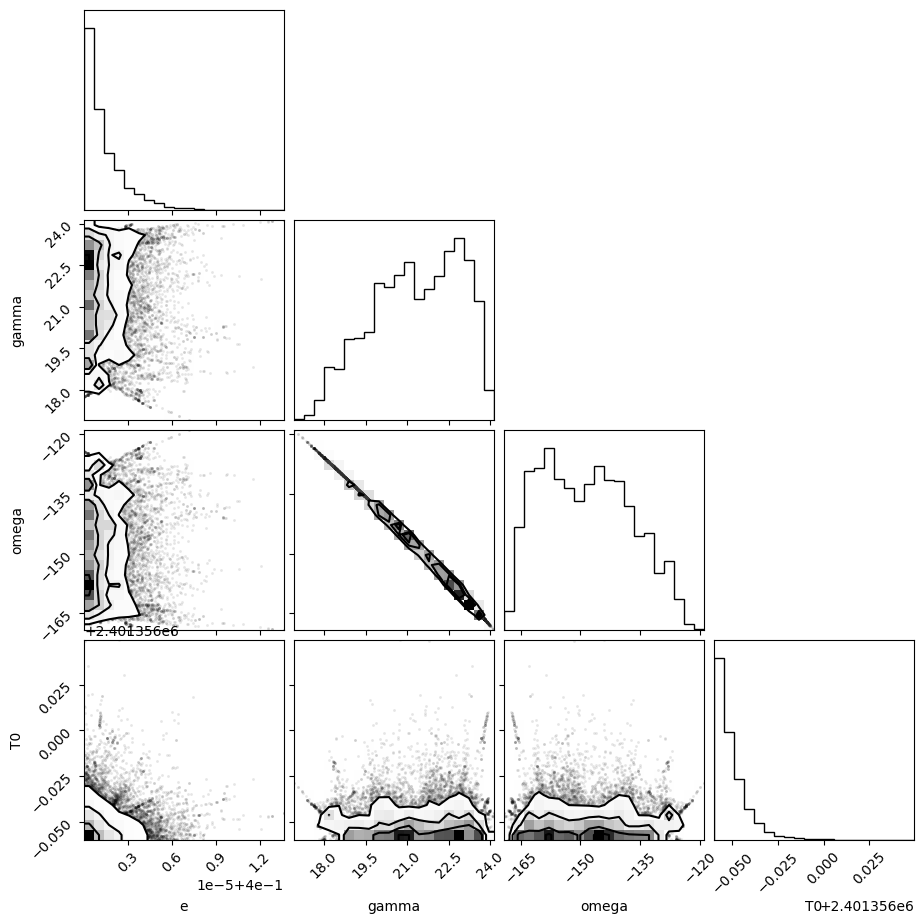

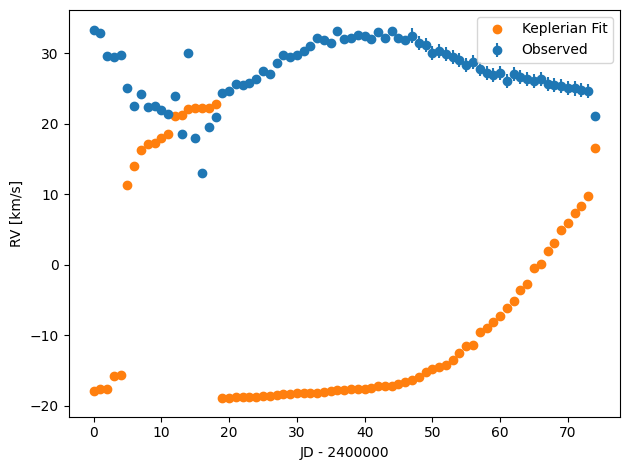

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import emcee

# === Load your data ===
df = pd.read_csv('HD104438_RVs.csv')  # Make sure the correct filename is used
t = df.iloc[:, 0].values  # Julian Date
rv_obs = df.iloc[:, 1].values  # Radial velocities
rv_err = df.iloc[:, 2].values  # RV uncertainties

# Ensure no zero/negative errors
rv_err[rv_err <= 0] = np.min(rv_err[rv_err > 0]) * 0.1
if np.any(np.isnan(rv_err)):
    raise ValueError("RV error contains NaNs!")

# === Fixed parameters from the paper ===
P = 13000  # days
K = 6.7    # km/s

# === Keplerian model ===
def keplerian_model(t, P, K, e, gamma, omega, T0):
    M = 2 * np.pi * (t - T0) / P
    M = np.mod(M, 2*np.pi)

    E = solve_kepler(M, e)


    # True anomaly
    nu = 2 * np.arctan(np.sqrt((1 + e) / (1 - e)) * np.tan(E / 2))

    # Radial velocity model
    rv = gamma + K * ((np.deg2rad(omega) + nu) + e * np.cos(np.deg2rad(omega)))
    return rv

# === Prior ===
def log_prior(params):
    e, gamma, omega, T0 = params
    if not (0.4 <= e <= 0.8): return -np.inf
    if not (15 <= gamma <= 40): return -np.inf
    if not (-180 <= omega <= 180): return -np.inf
    if not (2000000 <= T0 <= 3000000): return -np.inf
    return 0.0

# === Likelihood ===
def log_likelihood(params, t, P, K, rv_obs, rv_err):
    e, gamma, omega, T0 = params
    model = keplerian_model(t, P, K, e, gamma, omega, T0)
    if np.any(np.isnan(model)):
        return -np.inf
    return -0.5 * np.sum(((rv_obs - model) / rv_err) ** 2 + np.log(2 * np.pi * rv_err ** 2))

# === Posterior ===
def log_probability(params, t, P, K, rv_obs, rv_err):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, t, P, K, rv_obs, rv_err)

# === Initial values from the paper ===
initial_params = np.array([0.58, 24.2, -80.0, 2401400])  # [e, gamma, omega, T0]
ndim = len(initial_params)
nwalkers = 2 * ndim

# === Walker initialization ===
scale = [0.01, 0.5, 5, 20]  # small scatter for walkers
np.random.seed(163)
pos = initial_params + scale * np.random.randn(nwalkers, ndim)

# Clip to stay within bounds
for p in pos:
    p[0] = np.clip(p[0], 0.4, 0.8)     # e
    p[1] = np.clip(p[1], 15, 40)       # gamma
    p[2] = np.clip(p[2], -180, 180)    # omega
    p[3] = np.clip(p[3], 2000000, 2800000)   # T0

# === Run MCMC ===
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(t, P, K, rv_obs, rv_err))

print("Running MCMC...")
sampler.run_mcmc(pos, 50000, progress=True)
print("MCMC complete.")

# === Extract and visualize the results ===
samples = sampler.get_chain(discard=10000, thin=15, flat=True)

import corner
labels = ['e', 'gamma', 'omega', 'T0']
fig = corner.corner(samples, labels=labels, truths=initial_params)
plt.show()

# === Plot best fit ===
best_fit = np.median(samples, axis=0)
rv_model = keplerian_model(t, P, K, *best_fit)

plt.errorbar(range(len(t)), rv_obs, yerr=rv_err, fmt='o', label='Observed')
plt.plot(range(len(t)), rv_model, 'o', label='Keplerian Fit')  # 'o' marker only, no line
plt.xlabel('JD - 2400000')
plt.ylabel('RV [km/s]')
plt.legend()
plt.tight_layout()
plt.show()



Running MCMC...


  0%|                                                 | 0/50000 [00:00<?, ?it/s]/opt/anaconda3/envs/pyasassn/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████| 50000/50000 [00:13<00:00, 3758.10it/s]


MCMC complete.


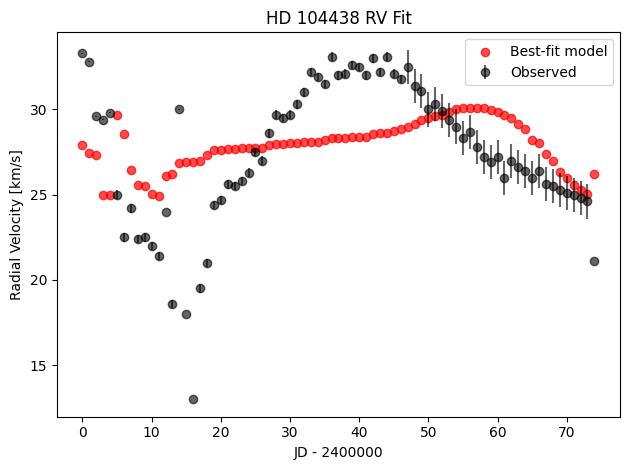

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import emcee

# Sanitize RV error
rv_err[rv_err <= 0] = np.min(rv_err[rv_err > 0]) * 0.1

def keplerian_model(t, P, K, e, gamma, omega_deg, T0):
    M = 2 * np.pi * (t - T0) / P
    M = np.mod(M, 2*np.pi)

    def solve_kepler(M, e, tol=1e-10, max_iter=100):
        E = M.copy()
        for _ in range(max_iter):
            delta = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
            E -= delta
            if np.all(np.abs(delta) < tol):
                break
        return E

    E = solve_kepler(M, e)
    nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                        np.sqrt(1 - e) * np.cos(E / 2))

    omega = np.radians(omega_deg)

    # Try flipping the sign here if needed:
    rv = gamma + K * (-np.cos(omega + nu) - e * np.cos(omega))


    
    return rv


# === Parameter Setup ===

# Fixed period and K from the paper
P = 10479
K = 2.6

# Physical prior bounds (used to normalize)
bounds = {
    'e': (0.01, 0.9),
    'gamma': (10, 50),
    'omega': (-180, 180),
    'T0': (1800, 3000)
}

def normalize(params):
    return [
        (params[0] - bounds['e'][0]) / (bounds['e'][1] - bounds['e'][0]),
        (params[1] - bounds['gamma'][0]) / (bounds['gamma'][1] - bounds['gamma'][0]),
        (params[2] - bounds['omega'][0]) / (bounds['omega'][1] - bounds['omega'][0]),
        (params[3] - bounds['T0'][0]) / (bounds['T0'][1] - bounds['T0'][0]),
    ]

def denormalize(norm_params):
    return [
        bounds['e'][0] + norm_params[0] * (bounds['e'][1] - bounds['e'][0]),
        bounds['gamma'][0] + norm_params[1] * (bounds['gamma'][1] - bounds['gamma'][0]),
        bounds['omega'][0] + norm_params[2] * (bounds['omega'][1] - bounds['omega'][0]),
        bounds['T0'][0] + norm_params[3] * (bounds['T0'][1] - bounds['T0'][0]),
    ]

# === Priors and Likelihood ===
def log_prior(theta):
    if np.any((theta < 0) | (theta > 1)):
        return -np.inf
    return 0.0

def log_likelihood(theta, t, rv_obs, rv_err):
    e, gamma, omega, T0 = denormalize(theta)
    model = keplerian_model(t, P, K, e, gamma, omega, T0)
    return -0.5 * np.sum(((rv_obs - model) / rv_err)**2 + np.log(2 * np.pi * rv_err**2))

def log_probability(theta, t, rv_obs, rv_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, rv_obs, rv_err)

# === MCMC Setup ===
ndim = 4
nwalkers = 32
np.random.seed(42)

initial_guess = normalize([0.3, 28.0, -60.0, 2401400  ])
pos = initial_guess + 1e-2 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(t, rv_obs, rv_err))

print("Running MCMC...")
sampler.run_mcmc(pos, 50000, progress=True)
print("MCMC complete.")

# === Extract Samples & Best Fit ===
samples = sampler.get_chain(discard=2000, flat=True)
best_fit = np.median(samples, axis=0)
e, gamma, omega, T0 = denormalize(best_fit)
rv_model = keplerian_model(t, P, K, e, gamma, omega, T0)

# === Plot ===
plt.errorbar(range(len(t)), rv_obs, yerr=rv_err, fmt='o', label='Observed', color='black', alpha=0.6)
plt.scatter(range(len(t)), rv_model, color='red', label='Best-fit model', alpha=0.7)
plt.xlabel('JD - 2400000')
plt.ylabel('Radial Velocity [km/s]')
plt.title("HD 104438 RV Fit")
plt.legend()
plt.tight_layout()
plt.show()


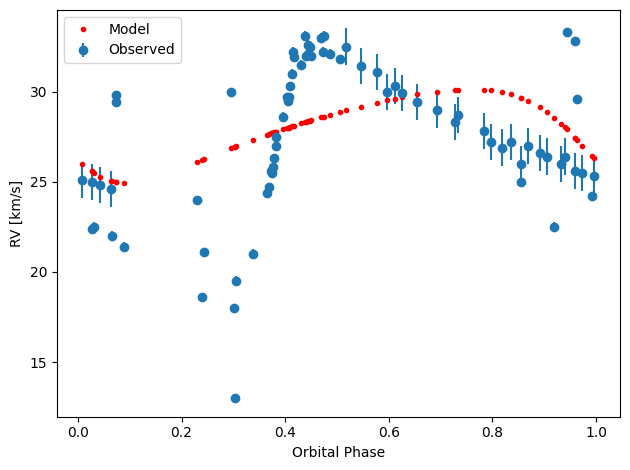

In [25]:
phase = ((t - T0) % P) / P
sorted_idx = np.argsort(phase)

plt.errorbar(phase[sorted_idx], rv_obs[sorted_idx], yerr=rv_err[sorted_idx], fmt='o', label='Observed')
plt.plot(phase[sorted_idx], rv_model[sorted_idx], '.', label='Model', color='red')
plt.xlabel("Orbital Phase")
plt.ylabel("RV [km/s]")
plt.legend()
plt.tight_layout()
plt.show()


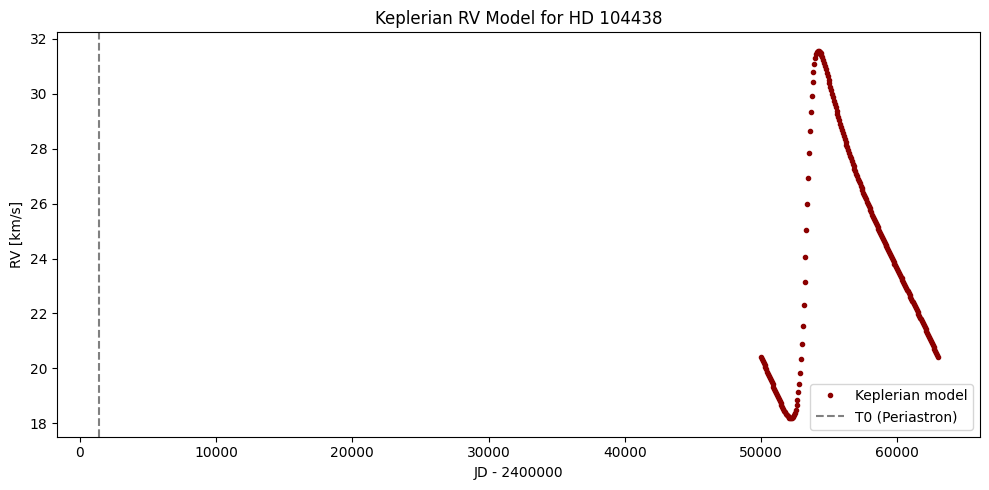

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated observation times (you can replace this with your actual JD values)
t = np.linspace(2450000, 2463000, 200)  # JD values

# Orbital parameters for HD 104438
P = 13000          # Orbital period [days]
K = 6.7            # Semi-amplitude [km/s]
e = 0.58           # Eccentricity
gamma = 24.2       # Systemic velocity [km/s]
omega_deg = -80    # Argument of periastron [deg]
T0 = 2401400       # Time of periastron [JD = 1400 + 2.4e6]

def keplerian_model(t, P, K, e, gamma, omega_deg, T0):
    M = 2 * np.pi * (t - T0) / P
    M = np.mod(M, 2 * np.pi)

    def kepler_solver(M, e, tol=1e-10, max_iter=100):
        E = M.copy()
        for _ in range(max_iter):
            delta = (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
            E -= delta
            if np.all(np.abs(delta) < tol):
                break
        return E

    E = kepler_solver(M, e)

    nu = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2),
                        np.sqrt(1 - e) * np.cos(E / 2))

    omega = np.radians(omega_deg)

    # RV equation
    rv = gamma + K * (np.cos(omega + nu) + e * np.cos(omega))
    return rv

# Generate model
rv_model = keplerian_model(t, P, K, e, gamma, omega_deg, T0)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(t - 2.4e6, rv_model, '.', color='darkred', label='Keplerian model')
plt.axvline(1400, color='gray', linestyle='--', label='T0 (Periastron)')
plt.xlabel("JD - 2400000")
plt.ylabel("RV [km/s]")
plt.title("Keplerian RV Model for HD 104438")
plt.legend()
plt.tight_layout()
plt.show()
